Portfolio valuation

Market value weighting

Interest rate scenario analysis

Yield curve shocks

Portfolio P&L attribution

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import CubicSpline

In [73]:
from pathlib import Path

ROOT = Path.cwd().parent

In [74]:
treasury = pd.read_csv(ROOT / "data/treasury_yields.csv")

In [75]:
# Create portfolio
maturities = [2,5,7,10,20]
names = ["2Y","5Y","7Y","10Y","20Y"]
notionals = np.array([2,3,1.5,2.5,1]) * 1e6
portfolio = pd.DataFrame({
    "Maturity": maturities,
    "Face": notionals,
    "Coupon": treasury.iloc[0][names]
})

portfolio

,Maturity,Face,Coupon
2Y,2,2000000.0,4.2
5Y,5,3000000.0,4.27
7Y,7,1500000.0,4.37
10Y,10,2500000.0,4.49
20Y,20,1000000.0,4.95


In [76]:
curve = pd.read_csv(ROOT / "data/continuous_zero_curve.csv")

spot_curve = CubicSpline(
    curve["Years"],
    curve["Spot"]
)


In [77]:
def discount_factor(t):

    r = spot_curve(t) / 100

    return 1 / (1 + r)**t


def cashflows(maturity, coupon_rate, freq = 2, face = 100):

    periods = int(maturity * freq)

    payment = (coupon_rate / 100 * face / freq)

    times = np.arange(1, periods+1) / freq

    cashflows = np.full(
        periods,
        payment
    )

    cashflows[-1] += face

    return times, cashflows

def price_bond(maturity, coupon_rate, face = 100, frequency = 2):

    times, cf = cashflows(maturity, coupon_rate, frequency,face)

    dfs = discount_factor(times)

    return np.sum(cf * dfs)

In [78]:
portfolio["Unit Price"] = portfolio.apply(
    lambda x:
    price_bond(
        maturity=x["Maturity"],
        coupon_rate=x["Coupon"]
    ),
    axis=1
)

portfolio

,Maturity,Face,Coupon,Unit Price
2Y,2,2000000.0,4.2,99.886010
5Y,5,3000000.0,4.27,99.554418
7Y,7,1500000.0,4.37,99.342777
10Y,10,2500000.0,4.49,98.961077
20Y,20,1000000.0,4.95,97.961892


In [79]:
portfolio["Market Value"] = (
    portfolio["Face"]
    * portfolio["Unit Price"]
    / 100
)

portfolio_value = portfolio["Market Value"].sum()

print(f"Portfolio Value: ${portfolio_value:,.2f}")

Portfolio Value: $9,928,140.25


Text(0.5, 1.0, 'Portfolio Allocation')

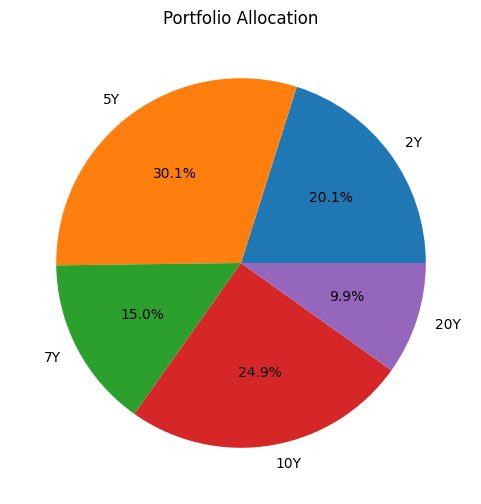

In [80]:
portfolio["Weight"] = (
    portfolio["Market Value"]
    /
    portfolio_value
)

plt.figure(figsize=(6,6))

plt.pie(
    portfolio["Weight"],
    labels=portfolio.index,
    autopct="%1.1f%%"
)

plt.title("Portfolio Allocation")

In [85]:
# BOOKMARK

In [81]:
# Yield curve shock functions

def parallel_shift(curve, shift):

    shocked = curve.copy()

    shocked["Spot"] += shift

    return shocked

def steepener(curve):

    shocked = curve.copy()

    shocked["Spot"] += (
        shocked["Years"]
        / shocked["Years"].max()
    )

    return shocked

def flattener(curve):

    shocked = curve.copy()

    shocked["Spot"] += (
        1
        -
        shocked["Years"]
        / shocked["Years"].max()
    )

    return shocked

def twist(curve):

    shocked = curve.copy()

    midpoint = shocked["Years"].median()

    shocked["Spot"] += np.where(
        shocked["Years"] < midpoint,
        0.5,
        -0.5
    )

    return shocked

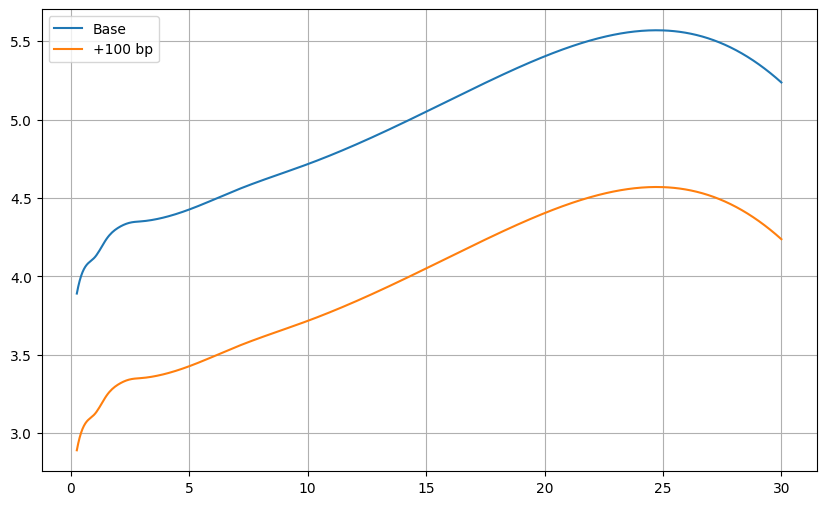

In [82]:
parallel_up = parallel_shift(
    curve,
    -1.00
)

plt.figure(figsize=(10,6))

plt.plot(
    curve["Years"],
    curve["Spot"],
    label="Base"
)

plt.plot(
    parallel_up["Years"],
    parallel_up["Spot"],
    label="+100 bp"
)

"""plt.plot(
    steepener["Years"],
    steepener["Spot"],
    label="Steepener"
)"""

plt.legend()

plt.grid()

In [83]:
# Reprice under stress
def price_portfolio(
    portfolio,
    curve
):

    spline = CubicSpline(
        curve["Years"],
        curve["Spot"]
    )

    def discount_factor(t):

        r = spline(t)/100

        return 1/(1+r)**t

    values = []

    for _, row in portfolio.iterrows():

        times, cf = cashflows(
            row["Maturity"],
            row["Coupon"]
        )

        price = np.sum(
            cf
            *
            discount_factor(times)
        )

        values.append(
            price
            *
            row["Face"]
            /100
        )

    return np.sum(values)

In [84]:
base_value = price_portfolio(
    portfolio,
    curve
)

parallel_value = price_portfolio(
    portfolio,
    parallel_up
)

pnl = parallel_value - base_value

pct = pnl / base_value * 100